In [33]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 966C-A36B

 Directory of c:\Users\chinthaparthy\Desktop

03/03/2026  10:34 PM    <DIR>          .
02/27/2026  04:13 PM    <DIR>          ..
06/12/2025  08:13 AM               806 200 km from the cursor - north east.txt
04/09/2025  09:33 AM            20,703 20170202_2_Model_SMPS_data.txt
07/15/2022  08:42 PM            21,820 20171011_6_Model_SMPS_data.txt
06/21/2025  11:07 AM    <DIR>          2018.03.28_nppcat
01/21/2026  11:06 AM    <DIR>          2022
11/30/2022  11:45 AM        59,130,734 20221130_Defense_v6.pptx
12/26/2025  10:51 PM            30,707 2025_data.xlsx
07/30/2025  03:39 PM               226 5.1,5.7,6.4,7.1,8,8.9,10,11.2,12.5,.txt
02/13/2026  10:52 PM            13,451 5_Zones.txt
02/27/2026  04:49 PM             4,898 ABI-L2-ACHTF_2019_339_keys.txt
02/27/2026  06:10 PM            14,398 ABI-L2-ACHTF_2019_340_keys.txt
02/27/2026  05:57 PM                 0 ABI-L2-RRQPE_2019_339_keys.txt
02/27/2026  06:06 PM       

In [34]:
datasets = xr.open_datasets(
    "fnl_20230114_18_00.grib2",
    engine="cfgrib"
)

print(len(datasets))
for d in datasets:
    print(d)

AttributeError: module 'xarray' has no attribute 'open_datasets'

In [ ]:
import xarray as xr

In [ ]:
import cfgrib

datasets = cfgrib.open_datasets("fnl_20230114_18_00.grib2")

print(len(datasets))

for ds in datasets:
    print(ds)

36
<xarray.Dataset> Size: 526kB
Dimensions:     (latitude: 181, longitude: 360)
Coordinates:
    time        datetime64[ns] 8B 2023-01-14T18:00:00
    step        timedelta64[ns] 8B 00:00:00
    atmosphere  float64 8B 0.0
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    valid_time  datetime64[ns] 8B 2023-01-14T18:00:00
Data variables:
    tcc         (latitude, longitude) float32 261kB ...
    refc        (latitude, longitude) float32 261kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
<xarray.Dataset> Size: 1MB
Dimensions:                (latitude: 181, longitude: 360)
Coordinates:
    time                   datetime64[ns] 8B 2023-01-14T18:00:00
 

In [ ]:
import s3fs
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
import os

# -----------------------------
# SETTINGS
# -----------------------------
START_DATE = "2017-01-01"
END_DATE   = "2017-01-02"

OUTDIR = "GOES16_ATTO_CTT"
os.makedirs(OUTDIR, exist_ok=True)

# ATTO region
lat_min, lat_max = -3.0, -1.0
lon_min, lon_max = -60.5, -57.5

BUCKET = "noaa-goes16"
PRODUCT = "ABI-L2-ACHTF"

# -----------------------------
# AWS connection
# -----------------------------
fs = s3fs.S3FileSystem(anon=True)

# -----------------------------
# time loop (hourly search)
# -----------------------------
times = pd.date_range(
    START_DATE,
    END_DATE,
    freq="1H"
)

for t in tqdm(times):

    year = t.strftime("%Y")
    doy  = t.strftime("%j")
    hour = t.strftime("%H")

    prefix = f"{BUCKET}/{PRODUCT}/{year}/{doy}/{hour}/"

    try:
        files = fs.ls(prefix)
    except:
        continue

    for file in files:

        filename = os.path.basename(file)
        outfile = f"{OUTDIR}/{filename}_ATTO.nc"

        # skip existing files (restart-safe)
        if os.path.exists(outfile):
            continue

        try:
            with fs.open(file) as f:
                ds = xr.open_dataset(f)

                # Cloud Top Temperature variable
                ctt = ds["HT"]

                # spatial subset using lat/lon arrays
                subset = ctt.where(
                    (ds.latitude >= lat_min) &
                    (ds.latitude <= lat_max) &
                    (ds.longitude >= lon_min) &
                    (ds.longitude <= lon_max),
                    drop=True
                )

                subset.to_netcdf(outfile)

        except Exception as e:
            print("Skipped:", filename, e)

C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_18944\2239349315.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range(
100%|██████████| 25/25 [00:08<00:00,  3.00it/s]


In [ ]:
# ============================================================
# GOES-16 Cloud Top Temperature download for ATTO (2017–2019)
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import s3fs
from tqdm import tqdm

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

START_DATE = "2019-07-01"   # reliable data starts mid-2017
END_DATE   = "2019-07-05"

OUTDIR = "GOES16_ATTO_CTT"
os.makedirs(OUTDIR, exist_ok=True)

# ATTO region box
lat_min, lat_max = -3.0, -1.0
lon_min, lon_max = -60.5, -57.5

BUCKET  = "noaa-goes16"
PRODUCT = "ABI-L2-ACHTF"

# ------------------------------------------------------------
# AWS connection
# ------------------------------------------------------------

fs = s3fs.S3FileSystem(anon=True)

# ------------------------------------------------------------
# TIME RANGE
# ------------------------------------------------------------

times = pd.date_range(
    START_DATE,
    END_DATE,
    freq="1h"
)

print("Total hours:", len(times))

# ------------------------------------------------------------
# FUNCTION: compute lat/lon grid (ONLY ONCE)
# ------------------------------------------------------------

def compute_latlon(ds):

    proj = ds["goes_imager_projection"]

    H = proj.perspective_point_height + proj.semi_major_axis
    lon0 = np.deg2rad(proj.longitude_of_projection_origin)
    r_eq = proj.semi_major_axis
    r_pol = proj.semi_minor_axis

    x = ds["x"].values
    y = ds["y"].values

    X, Y = np.meshgrid(x, y)

    a = np.sin(X)**2 + (np.cos(X)**2)*(
        np.cos(Y)**2 + (r_eq**2/r_pol**2)*np.sin(Y)**2
    )
    b = -2*H*np.cos(X)*np.cos(Y)
    c = H**2 - r_eq**2

    rs = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)

    sx = rs*np.cos(X)*np.cos(Y)
    sy = -rs*np.sin(X)
    sz = rs*np.cos(X)*np.sin(Y)

    lat = np.rad2deg(
        np.arctan((r_eq**2/r_pol**2)*(sz/np.sqrt((H-sx)**2 + sy**2)))
    )

    lon = np.rad2deg(lon0 - np.arctan(sy/(H-sx)))

    return lat, lon


# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------

lat_grid = None
lon_grid = None

for t in tqdm(times):

    year = t.strftime("%Y")
    doy  = t.strftime("%j")
    hour = t.strftime("%H")

    prefix = f"{BUCKET}/{PRODUCT}/{year}/{doy}/{hour}/"

    try:
        files = fs.ls(prefix)
    except:
        continue

    for file in files:

        filename = os.path.basename(file)
        outfile = os.path.join(OUTDIR, filename + "_ATTO.nc")

        if os.path.exists(outfile):
            continue

        try:
            with fs.open(file) as f:

                ds = xr.open_dataset(f)

                # compute lat/lon ONLY once
                if lat_grid is None:
                    print("Computing geolocation grid...")
                    lat_grid, lon_grid = compute_latlon(ds)

                ctt = ds["HT"]

                mask = (
                    (lat_grid >= lat_min) &
                    (lat_grid <= lat_max) &
                    (lon_grid >= lon_min) &
                    (lon_grid <= lon_max)
                )

                subset = ctt.where(mask)

                subset = subset.dropna(dim="y", how="all")
                subset = subset.dropna(dim="x", how="all")

                # debug check
                if subset.size == 0:
                    continue

                subset.to_netcdf(outfile)

        except Exception as e:
            print("Skipped:", filename, e)

print("Download complete.")

Total hours: 97


100%|██████████| 97/97 [00:26<00:00,  3.61it/s]

Download complete.


In [ ]:
import s3fs

# anonymous access
fs = s3fs.S3FileSystem(anon=True)

# list root bucket
print("Checking bucket...")
root = fs.ls("noaa-goes16")

print("Connected ✅")
print("Some folders:")
print(root[:20])

Checking bucket...
Connected ✅
Some folders:
['noaa-goes16/ABI-L1b-RadC', 'noaa-goes16/ABI-L1b-RadC-Reproc', 'noaa-goes16/ABI-L1b-RadF', 'noaa-goes16/ABI-L1b-RadF-Reproc', 'noaa-goes16/ABI-L1b-RadM', 'noaa-goes16/ABI-L2-ACHA2KMC', 'noaa-goes16/ABI-L2-ACHA2KMF', 'noaa-goes16/ABI-L2-ACHA2KMM', 'noaa-goes16/ABI-L2-ACHAC', 'noaa-goes16/ABI-L2-ACHAF', 'noaa-goes16/ABI-L2-ACHAM', 'noaa-goes16/ABI-L2-ACHP2KMC', 'noaa-goes16/ABI-L2-ACHP2KMF', 'noaa-goes16/ABI-L2-ACHP2KMM', 'noaa-goes16/ABI-L2-ACHTF', 'noaa-goes16/ABI-L2-ACHTM', 'noaa-goes16/ABI-L2-ACMC', 'noaa-goes16/ABI-L2-ACMF', 'noaa-goes16/ABI-L2-ACMM', 'noaa-goes16/ABI-L2-ACTPC']


In [ ]:
# List years under ACHTF
years = fs.ls("noaa-goes16/ABI-L2-ACHTF")
print("Available years:")
print(years)

Available years:
['noaa-goes16/ABI-L2-ACHTF/2019', 'noaa-goes16/ABI-L2-ACHTF/2020', 'noaa-goes16/ABI-L2-ACHTF/2021', 'noaa-goes16/ABI-L2-ACHTF/2022', 'noaa-goes16/ABI-L2-ACHTF/2023', 'noaa-goes16/ABI-L2-ACHTF/2024', 'noaa-goes16/ABI-L2-ACHTF/2025']


In [ ]:
# List all days in 2019
days_2019 = fs.ls("noaa-goes16/ABI-L2-ACHTF/2019")
print("First few days of 2019:")
print(days_2019[:5])  # just the first 5 days to check

# Pick the first day to inspect hours
first_day = days_2019[0]
hours = fs.ls(first_day)
print(f"Hours available in day {first_day.split('/')[-1]}:")
print(hours[:5])

# Pick the first hour to list files
first_hour = hours[0]
files = fs.ls(first_hour)
print(f"Files in first hour ({first_hour.split('/')[-1]}):")
print(files[:5])

First few days of 2019:
['noaa-goes16/ABI-L2-ACHTF/2019/339', 'noaa-goes16/ABI-L2-ACHTF/2019/340', 'noaa-goes16/ABI-L2-ACHTF/2019/341', 'noaa-goes16/ABI-L2-ACHTF/2019/342', 'noaa-goes16/ABI-L2-ACHTF/2019/343']
Hours available in day 339:
['noaa-goes16/ABI-L2-ACHTF/2019/339/15', 'noaa-goes16/ABI-L2-ACHTF/2019/339/16', 'noaa-goes16/ABI-L2-ACHTF/2019/339/17', 'noaa-goes16/ABI-L2-ACHTF/2019/339/18', 'noaa-goes16/ABI-L2-ACHTF/2019/339/19']
Files in first hour (15):
['noaa-goes16/ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc']


In [ ]:
import xarray as xr
import fsspec

file_path = "noaa-goes16/ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc"

# Open dataset via fsspec S3FileSystem with anonymous access
fs = fsspec.filesystem("s3", anon=True)
with fs.open(file_path) as f:
    ds = xr.open_dataset(f, engine="h5netcdf")

# Inspect variables
print(ds.data_vars)

Data variables:
    TEMP                                    (y, x) float32 118MB ...
    DQF                                     (y, x) float32 118MB ...
    time_bounds                             (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                  int32 4B ...
    y_image_bounds                          (number_of_image_bounds) float32 8B ...
    x_image_bounds                          (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat          float32 4B ...
    nominal_satellite_subpoint_lon          float32 4B ...
    nominal_satellite_height                float32 4B ...
    geospatial_lat_lon_extent               float32 4B ...
    outlier_pixels                          float64 8B ...
    minimum_cloud_top_temperature           float32 4B ...
    maximum_cloud_top_temperature           float32 4B ...
    mean_cloud_top_temperature              float32 4B ...
    std_dev_cloud_top_temperature           float32 4B ...

Data variables:
    TEMP                                    (y, x) float32 118MB ...
    DQF                                     (y, x) float32 118MB ...
    time_bounds                             (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                  int32 4B ...
    y_image_bounds                          (number_of_image_bounds) float32 8B ...
    x_image_bounds                          (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat          float32 4B ...
    nominal_satellite_subpoint_lon          float32 4B ...
    nominal_satellite_height                float32 4B ...
    geospatial_lat_lon_extent               float32 4B ...
    outlier_pixels                          float64 8B ...
    minimum_cloud_top_temperature           float32 4B ...
    maximum_cloud_top_temperature           float32 4B ...
    mean_cloud_top_temperature              float32 4B ...
    std_dev_cloud_top_temperature           float32 4B ...

ValueError: I/O operation on closed file.

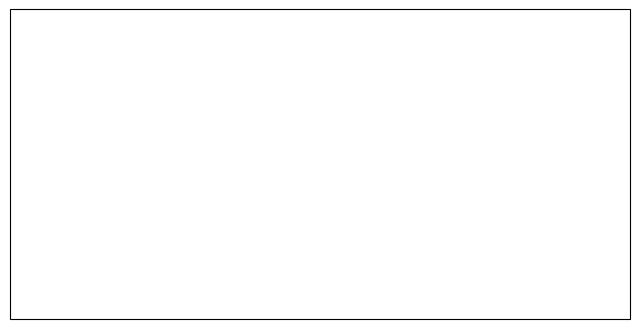

In [ ]:
import xarray as xr
import s3fs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Connect to NOAA's public S3 anonymously
fs = s3fs.S3FileSystem(anon=True)

# Remote file path
file_path = "noaa-goes16/ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc"

# Open S3 file via h5netcdf engine
with fs.open(file_path, 'rb') as f:
    ds = xr.open_dataset(f, engine="h5netcdf")

# Inspect variables
print(ds.data_vars)

# Example: Plot ATTO region
lat_min, lat_max = -2.2, -1.9
lon_min, lon_max = -59.0, -58.5

plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ds['TEMP'].plot.imshow(
    ax=ax,
    origin='upper',
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap='plasma'
)
ax.coastlines()
plt.title("GOES-16 ABI Cloud Top Temperature (ATTO Region)")
plt.show()

<xarray.DataArray 'TEMP' (y: 5424, x: 5424)> Size: 118MB
[29419776 values with dtype=float32]
Coordinates:
    t                   datetime64[ns] 8B ...
  * y                   (y) float32 22kB 0.1518 0.1518 ... -0.1518 -0.1518
  * x                   (x) float32 22kB -0.1518 -0.1518 ... 0.1518 0.1518
    y_image             float32 4B ...
    x_image             float32 4B ...
    local_zenith_angle  float32 4B ...
    solar_zenith_angle  float32 4B ...
Attributes:
    long_name:            ABI L2+ Cloud Top Temperature
    standard_name:        air_temperature_at_cloud_top
    valid_range:          [ 0 -6]
    units:                K
    resolution:           y: 0.000056 rad x: 0.000056 rad
    grid_mapping:         goes_imager_projection
    cell_methods:         local_zenith_angle: point (good quality pixel produ...
    ancillary_variables:  DQF


c:\Users\chinthaparthy\AppData\Local\anaconda3\envs\gpm_env\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


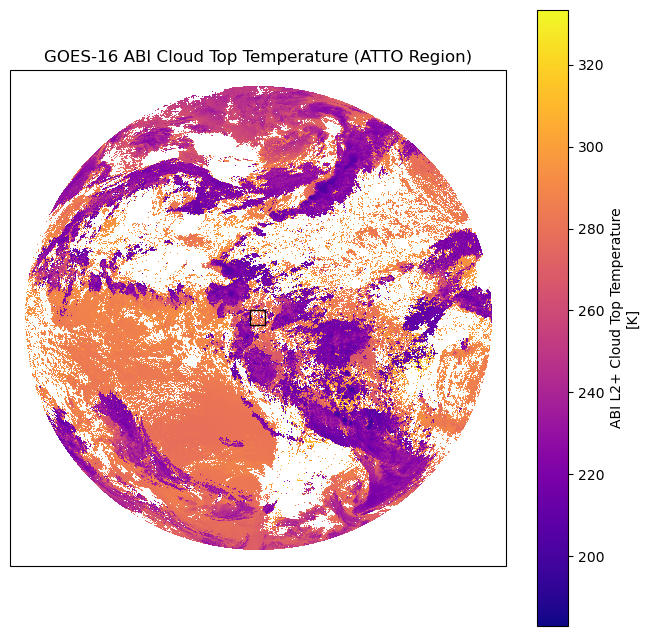

In [ ]:
import xarray as xr
import s3fs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fs = s3fs.S3FileSystem(anon=True)
file_path = "noaa-goes16/ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc"

# Open the S3 file and keep it in memory
f = fs.open(file_path, 'rb')
ds = xr.open_dataset(f, engine="h5netcdf")  # do NOT close f yet

# Now you can safely access variables
print(ds['TEMP'])

# Plot example (ATTO region)
lat_min, lat_max = -2.2, -1.9
lon_min, lon_max = -59.0, -58.5

plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ds['TEMP'].plot.imshow(
    ax=ax,
    origin='upper',
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap='plasma'
)
ax.coastlines()
plt.title("GOES-16 ABI Cloud Top Temperature (ATTO Region)")
plt.show()

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# --- choose what you want to list ---
bucket = "noaa-goes16"
product = "ABI-L2-ACHTF"
year = 2019
doy = 339          # day-of-year (001–366)
hour = 15          # 00–23

prefix = f"{product}/{year}/{doy:03d}/{hour:02d}/"

# --- anonymous (no-sign-request) S3 client ---
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

# --- list all objects (handles >1000 via paginator) ---
paginator = s3.get_paginator("list_objects_v2")
pages = paginator.paginate(Bucket=bucket, Prefix=prefix)

keys = []
for page in pages:
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith(".nc"):
            keys.append(key)

print(f"Found {len(keys)} files under s3://{bucket}/{prefix}")
for k in keys[:20]:
    print(k)

# Optional: build HTTPS links for each file
https_urls = [f"https://{bucket}.s3.amazonaws.com/{k}" for k in keys]


Found 1 files under s3://noaa-goes16/ABI-L2-ACHTF/2019/339/15/
ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc


In [ ]:
for h in [14, 15, 16]:
    prefix = f"{product}/{year}/{doy:03d}/{h:02d}/"
    pages = s3.get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=prefix)
    keys = [obj["Key"] for page in pages for obj in page.get("Contents", []) if obj["Key"].endswith(".nc")]
    print(h, len(keys), keys[:2])


14 0 []
15 1 ['ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc']
16 6 ['ABI-L2-ACHTF/2019/339/16/OR_ABI-L2-ACHTF-M6_G16_s20193391600198_e20193391609506_c20193391611297.nc', 'ABI-L2-ACHTF/2019/339/16/OR_ABI-L2-ACHTF-M6_G16_s20193391610198_e20193391619506_c20193391621410.nc']


In [ ]:
import re
from datetime import datetime, timezone
import boto3
from botocore import UNSIGNED
from botocore.config import Config

bucket = "noaa-goes16"
product = "ABI-L2-ACHTF"
year = 2019
doy = 339

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

# list whole day (24 hour prefixes)
keys = []
for hour in range(24):
    prefix = f"{product}/{year}/{doy:03d}/{hour:02d}/"
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            k = obj["Key"]
            if k.endswith(".nc"):
                keys.append(k)

# parse scan start time from filename: _sYYYYJJJHHMMSSs
pat = re.compile(r"_s(\d{4})(\d{3})(\d{2})(\d{2})(\d{2})\d?_")
def start_time_utc(key: str) -> datetime:
    m = pat.search(key)
    Y, J, hh, mm, ss = map(int, m.groups())
    return datetime.strptime(f"{Y} {J} {hh} {mm} {ss}", "%Y %j %H %M %S").replace(tzinfo=timezone.utc)

# choose the file closest to each hour
by_hour = {h: [] for h in range(24)}
for k in keys:
    t = start_time_utc(k)
    by_hour[t.hour].append((t, k))

hourly_keys = []
for h in range(24):
    if not by_hour[h]:
        continue
    target = datetime(by_hour[h][0][0].year, by_hour[h][0][0].month, by_hour[h][0][0].day, h, 0, tzinfo=timezone.utc)
    t_best, k_best = min(by_hour[h], key=lambda tk: abs((tk[0] - target).total_seconds()))
    hourly_keys.append(k_best)

print("Hourly (1 per hour) files:")
for k in hourly_keys:
    print(k)


Hourly (1 per hour) files:
ABI-L2-ACHTF/2019/339/15/OR_ABI-L2-ACHTF-M6_G16_s20193391550198_e20193391559506_c20193391601118.nc
ABI-L2-ACHTF/2019/339/16/OR_ABI-L2-ACHTF-M6_G16_s20193391600198_e20193391609506_c20193391611297.nc
ABI-L2-ACHTF/2019/339/17/OR_ABI-L2-ACHTF-M6_G16_s20193391700196_e20193391709503_c20193391711329.nc
ABI-L2-ACHTF/2019/339/18/OR_ABI-L2-ACHTF-M6_G16_s20193391800196_e20193391809503_c20193391811312.nc
ABI-L2-ACHTF/2019/339/19/OR_ABI-L2-ACHTF-M6_G16_s20193391900196_e20193391909503_c20193391911310.nc
ABI-L2-ACHTF/2019/339/20/OR_ABI-L2-ACHTF-M6_G16_s20193392000195_e20193392009503_c20193392011330.nc
ABI-L2-ACHTF/2019/339/21/OR_ABI-L2-ACHTF-M6_G16_s20193392100195_e20193392109503_c20193392111321.nc
ABI-L2-ACHTF/2019/339/22/OR_ABI-L2-ACHTF-M6_G16_s20193392200195_e20193392209503_c20193392211314.nc
ABI-L2-ACHTF/2019/339/23/OR_ABI-L2-ACHTF-M6_G16_s20193392300195_e20193392309503_c20193392311285.nc


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

bucket = "noaa-goes16"
product = "ABI-L2-ACHTF"
year = 2019
doy = 340  # 001–366

day_prefix = f"{product}/{year}/{doy:03d}/"   # <-- note: no hour here

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

keys = []
for page in paginator.paginate(Bucket=bucket, Prefix=day_prefix):
    for obj in page.get("Contents", []):
        k = obj["Key"]
        if k.endswith(".nc"):
            keys.append(k)

print(f"Found {len(keys)} .nc files under s3://{bucket}/{day_prefix}")
for k in keys[:50]:
    print(k)

# Optional: write to a text file
with open(f"{product}_{year}_{doy:03d}_keys.txt", "w") as f:
    f.write("\n".join(keys))


Found 144 .nc files under s3://noaa-goes16/ABI-L2-ACHTF/2019/340/
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400000195_e20193400009503_c20193400011282.nc
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400010195_e20193400019503_c20193400021348.nc
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400020195_e20193400029503_c20193400031080.nc
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400030195_e20193400039503_c20193400041197.nc
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400040195_e20193400049503_c20193400051230.nc
ABI-L2-ACHTF/2019/340/00/OR_ABI-L2-ACHTF-M6_G16_s20193400050195_e20193400059503_c20193400101122.nc
ABI-L2-ACHTF/2019/340/01/OR_ABI-L2-ACHTF-M6_G16_s20193400100195_e20193400109503_c20193400111261.nc
ABI-L2-ACHTF/2019/340/01/OR_ABI-L2-ACHTF-M6_G16_s20193400110195_e20193400119503_c20193400121341.nc
ABI-L2-ACHTF/2019/340/01/OR_ABI-L2-ACHTF-M6_G16_s20193400120195_e20193400129503_c20193400131071.nc
ABI-L2-ACHTF/2019/340/01/OR_ABI-L2-ACHTF-M6

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
bucket = "noaa-goes16"

paginator = s3.get_paginator("list_objects_v2")

prefixes = []
for page in paginator.paginate(Bucket=bucket, Delimiter="/"):
    for cp in page.get("CommonPrefixes", []):
        prefixes.append(cp["Prefix"].rstrip("/"))

# sort + show a few
prefixes = sorted(prefixes)
print("Number of top-level prefixes:", len(prefixes))
for p in prefixes[:100]:
    print(p)


Number of top-level prefixes: 102
ABI-L1b-RadC
ABI-L1b-RadC-Reproc
ABI-L1b-RadF
ABI-L1b-RadF-Reproc
ABI-L1b-RadM
ABI-L2-ACHA2KMC
ABI-L2-ACHA2KMF
ABI-L2-ACHA2KMM
ABI-L2-ACHAC
ABI-L2-ACHAF
ABI-L2-ACHAM
ABI-L2-ACHP2KMC
ABI-L2-ACHP2KMF
ABI-L2-ACHP2KMM
ABI-L2-ACHTF
ABI-L2-ACHTM
ABI-L2-ACMC
ABI-L2-ACMF
ABI-L2-ACMM
ABI-L2-ACTPC
ABI-L2-ACTPF
ABI-L2-ACTPM
ABI-L2-ADPC
ABI-L2-ADPF
ABI-L2-ADPM
ABI-L2-AICEF
ABI-L2-AITAF
ABI-L2-AODC
ABI-L2-AODF
ABI-L2-BRFC
ABI-L2-BRFF
ABI-L2-BRFM
ABI-L2-CCLC
ABI-L2-CCLF
ABI-L2-CCLM
ABI-L2-CMIPC
ABI-L2-CMIPF
ABI-L2-CMIPM
ABI-L2-COD2KMF
ABI-L2-CODC
ABI-L2-CODF
ABI-L2-CPSC
ABI-L2-CPSF
ABI-L2-CPSM
ABI-L2-CTPC
ABI-L2-CTPF
ABI-L2-DMWC
ABI-L2-DMWF
ABI-L2-DMWM
ABI-L2-DMWVC
ABI-L2-DMWVF
ABI-L2-DMWVM
ABI-L2-DSIC
ABI-L2-DSIF
ABI-L2-DSIM
ABI-L2-DSRC
ABI-L2-DSRF
ABI-L2-DSRM
ABI-L2-FDCC
ABI-L2-FDCF
ABI-L2-FDCM
ABI-L2-FSCC
ABI-L2-FSCF
ABI-L2-FSCM
ABI-L2-LSAC
ABI-L2-LSAF
ABI-L2-LSAM
ABI-L2-LST2KMF
ABI-L2-LSTC
ABI-L2-LSTF
ABI-L2-LSTM
ABI-L2-LVMPC
ABI-L2-LVMPF
ABI-L2-LVMPM
ABI-L2-LVT

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

bucket = "noaa-goes16"
product = "ABI-L2-RRQPEF"   # <-- note the trailing F (full disk) [file:162]
year = 2019
doy = 340  # 001–366

day_prefix = f"{product}/{year}/{doy:03d}/"

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

keys = []
for page in paginator.paginate(Bucket=bucket, Prefix=day_prefix):
    for obj in page.get("Contents", []):
        k = obj["Key"]
        if k.endswith(".nc"):
            keys.append(k)

print(f"Found {len(keys)} .nc files under s3://{bucket}/{day_prefix}")
for k in keys[:50]:
    print(k)

with open(f"{product}_{year}_{doy:03d}_keys.txt", "w") as f:
    f.write("\n".join(keys))


Found 144 .nc files under s3://noaa-goes16/ABI-L2-RRQPEF/2019/340/
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400000195_e20193400009503_c20193400010003.nc
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400010195_e20193400019503_c20193400020023.nc
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400020195_e20193400029503_c20193400029595.nc
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400030195_e20193400039503_c20193400039595.nc
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400040195_e20193400049503_c20193400049598.nc
ABI-L2-RRQPEF/2019/340/00/OR_ABI-L2-RRQPEF-M6_G16_s20193400050195_e20193400059503_c20193400059594.nc
ABI-L2-RRQPEF/2019/340/01/OR_ABI-L2-RRQPEF-M6_G16_s20193400100195_e20193400109503_c20193400110003.nc
ABI-L2-RRQPEF/2019/340/01/OR_ABI-L2-RRQPEF-M6_G16_s20193400110195_e20193400119503_c20193400120003.nc
ABI-L2-RRQPEF/2019/340/01/OR_ABI-L2-RRQPEF-M6_G16_s20193400120195_e20193400129503_c20193400130003.nc
ABI-L2-RRQPEF/2019/340/0

In [ ]:
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config

bucket = "noaa-goes16"
products = ["ABI-L2-ACHTF", "ABI-L2-RRQPEF"]
year = 2020
output_root = "./goes16_2020"

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

def download_year(product):
    print(f"\nProcessing {product} for {year}...")

    for doy in range(1, 367):  # 2020 is leap year
        day_prefix = f"{product}/{year}/{doy:03d}/"

        for page in paginator.paginate(Bucket=bucket, Prefix=day_prefix):
            for obj in page.get("Contents", []):
                key = obj["Key"]

                if not key.endswith(".nc"):
                    continue

                local_path = os.path.join(output_root, key)
                os.makedirs(os.path.dirname(local_path), exist_ok=True)

                if os.path.exists(local_path):
                    continue  # skip existing files

                print(f"Downloading {key}")
                s3.download_file(bucket, key, local_path)

for product in products:
    download_year(product)

print("\nDownload complete.")


Processing ABI-L2-ACHTF for 2020...


KeyboardInterrupt: 

In [2]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import xarray as xr
from pyproj import Proj
import pandas as pd
import os

# =========================
# ATTO coordinates
lat_atto = -2.1483
lon_atto = -59.0033

# GOES-16 S3 bucket and products
bucket = "noaa-goes16"
products = ["ABI-L2-ACHTF", "ABI-L2-RRQPEF"]
year = 2020

# Local storage base folder
base_dir = "GOES16"

# Setup S3 client (unsigned)
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

# Results storage
results = []

# =========================
# Test for one day (DOY 13)
test_doy = 13
hours = range(24)  # 0..23

for doy in [test_doy]:
    for hour in hours:
        for product in products:
            prefix = f"{product}/{year}/{doy:03d}/{hour:02d}/"

            # Grab first file in this hour
            first_file = None
            for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
                for obj in page.get("Contents", []):
                    if obj["Key"].endswith(".nc"):
                        first_file = obj["Key"]
                        break
                if first_file:
                    break

            if not first_file:
                continue  # no file for this hour

            # Local storage path
            local_dir = os.path.join(base_dir, product, str(year), f"{doy:03d}", f"{hour:02d}")
            os.makedirs(local_dir, exist_ok=True)
            local_file = os.path.join(local_dir, first_file.split("/")[-1].split("\\")[-1])

            # Download if not already exists
            if not os.path.exists(local_file):
                s3.download_file(bucket, first_file, local_file)

            # Open NetCDF
            ds = xr.open_dataset(local_file)

            # Projection-aware extraction
            proj_info = ds.goes_imager_projection
            proj = Proj(proj='geos',
                        h=proj_info.perspective_point_height,
                        lon_0=proj_info.longitude_of_projection_origin,
                        sweep=proj_info.sweep_angle_axis)
            x, y = proj(lon_atto, lat_atto)

            # --- Robust datetime extraction (scalar or array) ---
            if "t" in ds:
                time_val = ds["t"].values
                if hasattr(time_val, "ndim") and time_val.ndim == 0:
                    dt = pd.to_datetime(time_val)  # scalar
                else:
                    dt = pd.to_datetime(time_val[0])  # first element of array
            else:
                print(f"No time variable in file: {local_file}, skipping")
                ds.close()
                continue

            # Extract variable
            if product == "ABI-L2-ACHTF":
                value = float(ds["TEMP"].sel(x=x, y=y, method="nearest").values)
                current = {"datetime": dt, "CTT_K": value}
            else:
                value = float(ds["RRQPE"].sel(x=x, y=y, method="nearest").values)
                current["Rain_mmhr"] = value
                current["datetime"] = dt
                results.append(current)

            ds.close()
            print(f"Downloaded & processed: {local_file}")

# =========================
# Save CSV
df = pd.DataFrame(results)
df.sort_values("datetime", inplace=True)
csv_file = f"ATTO_GOES16_2020_DOY{test_doy}_hourly_first_file.csv"
df.to_csv(csv_file, index=False)
print(f"CSV saved: {csv_file}")

Downloaded & processed: GOES16\ABI-L2-ACHTF\2020\013\00\OR_ABI-L2-ACHTF-M6_G16_s20200130000201_e20200130009509_c20200130011461.nc
Downloaded & processed: GOES16\ABI-L2-RRQPEF\2020\013\00\OR_ABI-L2-RRQPEF-M6_G16_s20200130000201_e20200130009509_c20200130010012.nc
Downloaded & processed: GOES16\ABI-L2-ACHTF\2020\013\01\OR_ABI-L2-ACHTF-M6_G16_s20200130100200_e20200130109508_c20200130111452.nc
Downloaded & processed: GOES16\ABI-L2-RRQPEF\2020\013\01\OR_ABI-L2-RRQPEF-M6_G16_s20200130100200_e20200130109508_c20200130110007.nc
Downloaded & processed: GOES16\ABI-L2-ACHTF\2020\013\02\OR_ABI-L2-ACHTF-M6_G16_s20200130200200_e20200130209507_c20200130211373.nc
Downloaded & processed: GOES16\ABI-L2-RRQPEF\2020\013\02\OR_ABI-L2-RRQPEF-M6_G16_s20200130200200_e20200130209508_c20200130210016.nc
Downloaded & processed: GOES16\ABI-L2-ACHTF\2020\013\03\OR_ABI-L2-ACHTF-M6_G16_s20200130300199_e20200130309507_c20200130311391.nc
Downloaded & processed: GOES16\ABI-L2-RRQPEF\2020\013\03\OR_ABI-L2-RRQPEF-M6_G16_s20

In [3]:
import xarray as xr

file = "GOES16/ABI-L2-ACHTF/2020/013/00/OR_ABI-L2-ACHTF-M6_G16_s20200130000201_e20200130009509_c20200130011461.nc"
ds = xr.open_dataset(file)

print(ds)
print("t variable info:", ds["t"])
print("t values:", ds["t"].values)

ds.close()

<xarray.Dataset> Size: 235MB
Dimensions:                                 (y: 5424, x: 5424,
                                             number_of_time_bounds: 2,
                                             number_of_image_bounds: 2,
                                             number_of_LZA_bounds: 2,
                                             number_of_SZA_bounds: 2)
Coordinates:
    t                                       datetime64[ns] 8B ...
  * y                                       (y) float32 22kB 0.1518 ... -0.1518
  * x                                       (x) float32 22kB -0.1518 ... 0.1518
    y_image                                 float32 4B ...
    x_image                                 float32 4B ...
    local_zenith_angle                      float32 4B ...
    solar_zenith_angle                      float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                number_of_LZA_bounds, number_of_SZA_bou

In [5]:
import xarray as xr
import pandas as pd

file = "GOES16/ABI-L2-ACHTF/2020/013/00/OR_ABI-L2-ACHTF-M6_G16_s20200130000201_e20200130009509_c20200130011461.nc"
ds = xr.open_dataset(file)

# t is scalar
dt = pd.Timestamp(ds["t"].values)
print(dt)  # 2020-01-13 00:05:05.516020096

ds.close()

2020-01-13 00:05:05.516020096


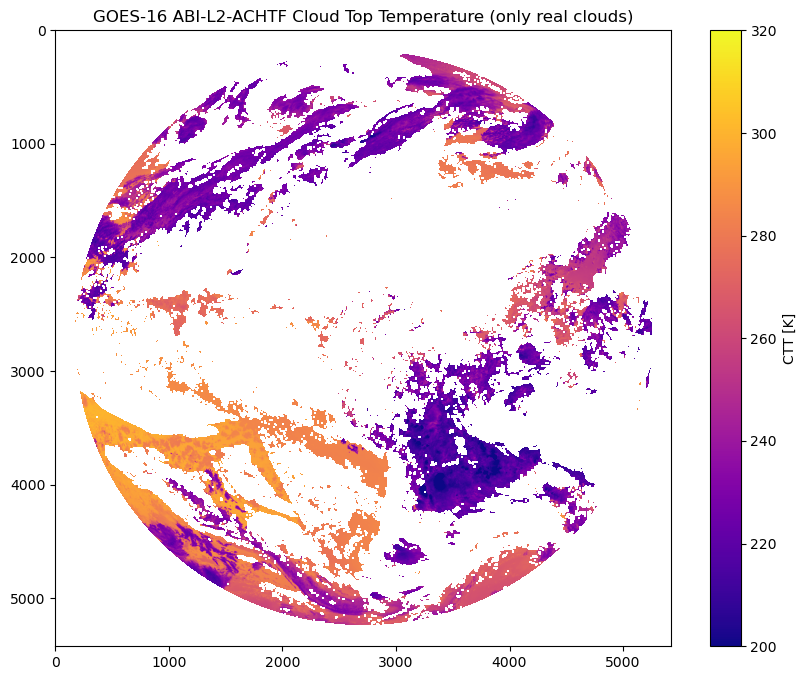

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Open dataset
file = "GOES16/ABI-L2-ACHTF/2020/013/00/OR_ABI-L2-ACHTF-M6_G16_s20200130000201_e20200130009509_c20200130011461.nc"
ds = xr.open_dataset(file)

# Extract TEMP and DQF
TEMP = ds["TEMP"].values
DQF = ds["DQF"].values

# Mask out zeros and invalid pixels
TEMP_masked = np.where((TEMP > 0) & (DQF == 0), TEMP, np.nan)

# Downsample for fast plotting
TEMP_small = TEMP_masked[::10, ::10]

# Plot
plt.figure(figsize=(10,8))
plt.imshow(TEMP_masked, origin='upper', cmap='plasma', vmin=200, vmax=320)
plt.colorbar(label='CTT [K]')
plt.title('GOES-16 ABI-L2-ACHTF Cloud Top Temperature (only real clouds)')
plt.show()

ds.close()

In [6]:
import xarray as xr
import numpy as np
from pyproj import Proj, Geod

# ------------------------
# ATTO coordinates
lat_atto = -2.1483
lon_atto = -59.0033

# ------------------------
# File path (example)
file = "GOES16/ABI-L2-ACHTF/2020/013/00/OR_ABI-L2-ACHTF-M6_G16_s20200130000201_e20200130009509_c20200130011461.nc"
ds = xr.open_dataset(file)

# ------------------------
# Projection info
proj_info = ds.goes_imager_projection
proj = Proj(proj='geos',
            h=proj_info.perspective_point_height,
            lon_0=proj_info.longitude_of_projection_origin,
            sweep=proj_info.sweep_angle_axis)

# Convert all x/y to lat/lon
x = ds['x'].values
y = ds['y'].values
X, Y = np.meshgrid(x, y)
lons, lats = proj(X, Y, inverse=True)

# ------------------------
# Mask valid pixels
TEMP = ds['TEMP'].values
DQF = ds['DQF'].values
valid_mask = (TEMP > 0) & (DQF == 0)

# ------------------------
# Compute distances to ATTO for all valid pixels
# Use Geod for accurate geodesic distance
geod = Geod(ellps="WGS84")

valid_lats = lats[valid_mask]
valid_lons = lons[valid_mask]
valid_temp = TEMP[valid_mask]

# Compute distance from ATTO
_, _, distances_m = geod.inv(np.full(valid_lons.shape, lon_atto),
                             np.full(valid_lats.shape, lat_atto),
                             valid_lons, valid_lats)

# Find nearest valid pixel
min_idx = np.argmin(distances_m)
nearest_ctt = valid_temp[min_idx]
nearest_distance_km = distances_m[min_idx] / 1000

print(f"Nearest valid CTT: {nearest_ctt:.2f} K")
print(f"Distance from ATTO: {nearest_distance_km:.2f} km")

ds.close()

Nearest valid CTT: 211.30 K
Distance from ATTO: 1796.11 km


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os
import concurrent.futures

# =========================
# GOES-16 S3 info
bucket = "noaa-goes16"
products = ["ABI-L2-ACHTF", "ABI-L2-RRQPEF"]
year = 2020
doy = 16  # 16th Jan
hours = range(24)
base_dir = "GOES16"

# Setup S3 client (unsigned)
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

# =========================
# Function to download first file for a product/hour
def download_first_file(product, hour):
    prefix = f"{product}/{year}/{doy:03d}/{hour:02d}/"
    first_file = None
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            if obj["Key"].endswith(".nc"):
                first_file = obj["Key"]
                break
        if first_file:
            break
    if not first_file:
        print(f"No file found for {product} hour {hour}")
        return

    local_dir = os.path.join(base_dir, product, str(year), f"{doy:03d}", f"{hour:02d}")
    os.makedirs(local_dir, exist_ok=True)
    local_file = os.path.join(local_dir, os.path.basename(first_file))

    if not os.path.exists(local_file):
        s3.download_file(bucket, first_file, local_file)
        print(f"Downloaded: {local_file}")
    else:
        print(f"Already exists: {local_file}")

# =========================
# Run downloads in parallel
tasks = [(p, h) for p in products for h in hours]
with concurrent.futures.ThreadPoolExecutor(max_workers=24) as executor:
    futures = [executor.submit(download_first_file, p, h) for p, h in tasks]
    concurrent.futures.wait(futures)

print("All downloads completed.")

Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\17\OR_ABI-L2-RRQPEF-M6_G16_s20200161700197_e20200161709504_c20200161710025.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\03\OR_ABI-L2-RRQPEF-M6_G16_s20200160300195_e20200160309503_c20200160310011.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\10\OR_ABI-L2-RRQPEF-M6_G16_s20200161000197_e20200161009505_c20200161010026.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\14\OR_ABI-L2-RRQPEF-M6_G16_s20200161400197_e20200161409505_c20200161410023.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\05\OR_ABI-L2-RRQPEF-M6_G16_s20200160500195_e20200160509503_c20200160510008.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\11\OR_ABI-L2-RRQPEF-M6_G16_s20200161100197_e20200161109505_c20200161110032.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\20\OR_ABI-L2-RRQPEF-M6_G16_s20200162000194_e20200162009502_c20200162010030.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\016\08\OR_ABI-L2-RRQPEF-M6_G16_s20200160800197_e20200160809505_c20200160810026.nc
Downloaded: GOES16\ABI-L2-RRQPEF\2020\01

In [1]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os
import concurrent.futures
from datetime import datetime, timedelta

# =========================
# GOES-16 S3 info
bucket = "noaa-goes16"
products = ["ABI-L2-ACHTF", "ABI-L2-RRQPEF"]
year = 2020
hours = range(24)
base_dir = "GOES16"

# Setup S3 client (unsigned)
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

# =========================
# Function to download first file for a product/hour/DOY
def download_first_file(product, doy, hour):
    prefix = f"{product}/{year}/{doy:03d}/{hour:02d}/"
    first_file = None
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            if obj["Key"].endswith(".nc"):
                first_file = obj["Key"]
                break
        if first_file:
            break
    if not first_file:
        print(f"No file found: {product} DOY {doy} hour {hour}")
        return

    local_dir = os.path.join(base_dir, product, str(year), f"{doy:03d}", f"{hour:02d}")
    os.makedirs(local_dir, exist_ok=True)
    local_file = os.path.join(local_dir, os.path.basename(first_file))

    if not os.path.exists(local_file):
        s3.download_file(bucket, first_file, local_file)
        print(f"Downloaded: {local_file}")
    else:
        print(f"Already exists: {local_file}")

# =========================
# Generate all DOY/hour/product combinations
start_date = datetime(year, 1, 1)
end_date = datetime(year + 1, 1, 1)
delta = end_date - start_date
doys = [d.timetuple().tm_yday for d in [start_date + timedelta(days=i) for i in range(delta.days)]]

tasks = [(p, doy, h) for p in products for doy in doys for h in hours]

# =========================
# Run downloads in parallel
with concurrent.futures.ThreadPoolExecutor(max_workers=24) as executor:
    futures = [executor.submit(download_first_file, p, doy, h) for p, doy, h in tasks]
    concurrent.futures.wait(futures)

print("All 2020 downloads completed.")

Already exists: GOES16\ABI-L2-ACHTF\2020\001\04\OR_ABI-L2-ACHTF-M6_G16_s20200010400216_e20200010409524_c20200010411474.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\03\OR_ABI-L2-ACHTF-M6_G16_s20200010300216_e20200010309524_c20200010311451.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\00\OR_ABI-L2-ACHTF-M6_G16_s20200010000216_e20200010009524_c20200010011462.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\05\OR_ABI-L2-ACHTF-M6_G16_s20200010500218_e20200010509526_c20200010511459.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\02\OR_ABI-L2-ACHTF-M6_G16_s20200010200216_e20200010209524_c20200010211460.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\08\OR_ABI-L2-ACHTF-M6_G16_s20200010800218_e20200010809526_c20200010811439.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\01\OR_ABI-L2-ACHTF-M6_G16_s20200010100216_e20200010109524_c20200010111439.nc
Already exists: GOES16\ABI-L2-ACHTF\2020\001\07\OR_ABI-L2-ACHTF-M6_G16_s20200010700218_e20200010709526_c20200010711430.nc
Already exists: GOES16\A